# 04. Histogram and Distribution

このノートブックでは、データの分布を確認する方法を学びます。

流れは次の通りです。

```text
個々のデータ
↓
度数分布表
↓
ヒストグラム
↓
分布の読み取り
```

平均値や標準偏差だけでは、データがどのように散らばっているのかは見えません。
度数分布表とヒストグラムを使うと、データの全体像を観察しやすくなります。

## 1. ライブラリの読み込み

この章では、次のライブラリを使います。

- `pandas`：表形式のデータを扱う
- `matplotlib`：グラフを描く
- `numpy`：数値計算を行う

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import sys
import subprocess
import importlib.util

packages = ["pandas", "matplotlib", "numpy"]

for package in packages:
    if importlib.util.find_spec(package) is None:
        print(f"{package} をインストールします。")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            package
        ])
    else:
        print(f"{package} はすでにインストールされています。")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("ライブラリの読み込みが完了しました。")


pandas をインストールします。
Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/65/b6/09b01cdbc15224e2850365192d17b7bdebb8bdbd8780ed221fcdf0d9a515/pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 925.9 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 136.3 kB/s eta 0:00:0000:0100:03
matplotlib はすでにインストールされています。
numpy はすでにインストールされています。
ライブラリの読み込みが完了しました。


## 2. テスト点数のデータ

まずは、あるクラスのテスト点数を例にします。

このまま数字を眺めても、全体の傾向は少しわかりにくいです。

In [5]:
scores = [45, 52, 58, 61, 63, 67, 70, 72, 75, 78, 80, 82, 85, 88, 92]
scores

[45, 52, 58, 61, 63, 67, 70, 72, 75, 78, 80, 82, 85, 88, 92]

## 3. データ数・平均値・標準偏差を確認する

まずは、基本的な代表値を確認します。

ただし、ここで大事なのは、平均値や標準偏差だけでは分布の形まではわからないということです。

In [6]:
score_series = pd.Series(scores)

print('データ数:', len(score_series))
print('平均値:', score_series.mean())
print('中央値:', score_series.median())
print('標準偏差:', score_series.std())

データ数: 15
平均値: 71.2
中央値: 72.0
標準偏差: 13.576239748703825


## 4. 度数分布表とは

度数分布表とは、データをいくつかの範囲に分け、それぞれの範囲に何個のデータが入っているかを表にしたものです。

- 度数：その範囲に入っているデータの数
- 階級：データを分ける範囲
- 階級幅：階級の幅

たとえば、40点以上50点未満、50点以上60点未満のような範囲が階級です。

## 5. 点数を階級に分ける

ここでは、10点ごとに階級を作ります。

```text
40点以上50点未満
50点以上60点未満
60点以上70点未満
...
```

In [7]:
bins = [40, 50, 60, 70, 80, 90, 101]
labels = [
    '40点以上50点未満',
    '50点以上60点未満',
    '60点以上70点未満',
    '70点以上80点未満',
    '80点以上90点未満',
    '90点以上100点以下'
]

score_groups = pd.cut(scores, bins=bins, labels=labels, right=False)
score_groups

['40点以上50点未満', '50点以上60点未満', '50点以上60点未満', '60点以上70点未満', '60点以上70点未満', ..., '80点以上90点未満', '80点以上90点未満', '80点以上90点未満', '80点以上90点未満', '90点以上100点以下']
Length: 15
Categories (6, str): ['40点以上50点未満' < '50点以上60点未満' < '60点以上70点未満' < '70点以上80点未満' < '80点以上90点未満' < '90点以上100点以下']

## 6. 度数分布表を作る

各階級に何人いるかを数えます。

これが、ヒストグラムのもとになるデータです。

In [8]:
frequency_table = score_groups.value_counts().sort_index()
frequency_table

40点以上50点未満     1
50点以上60点未満     2
60点以上70点未満     3
70点以上80点未満     4
80点以上90点未満     4
90点以上100点以下    1
Name: count, dtype: int64

## 7. 度数分布表を表として見やすくする

`DataFrame` にすると、表として扱いやすくなります。

In [9]:
frequency_df = pd.DataFrame({
    '点数の範囲': frequency_table.index,
    '人数': frequency_table.values
})

frequency_df

,点数の範囲,人数
0,40点以上50点未満,1
1,50点以上60点未満,2
2,60点以上70点未満,3
3,70点以上80点未満,4
4,80点以上90点未満,4
5,90点以上100点以下,1


## 8. 相対度数を追加する

相対度数とは、全体に対する割合です。

人数だけでなく割合を見ることで、別のクラスや別のデータとも比較しやすくなります。

In [10]:
frequency_df['相対度数'] = frequency_df['人数'] / frequency_df['人数'].sum()
frequency_df['相対度数(%)'] = frequency_df['相対度数'] * 100
frequency_df

,点数の範囲,人数,相対度数,相対度数(%)
0,40点以上50点未満,1,0.066667,6.666667
1,50点以上60点未満,2,0.133333,13.333333
2,60点以上70点未満,3,0.200000,20.000000
3,70点以上80点未満,4,0.266667,26.666667
4,80点以上90点未満,4,0.266667,26.666667
5,90点以上100点以下,1,0.066667,6.666667


## 9. 度数分布表を棒グラフにする

度数分布表を棒グラフにすると、どの範囲にデータが多いかを視覚的に確認できます。

この考え方が、次のヒストグラムにつながります。

/home/siwuser/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/siwuser/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20197 (\N{CJK UNIFIED IDEOGRAPH-4EE5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/siwuser/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/siwuser/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/siwuser/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28288 (\N{CJK UNIFIED IDEOGRAPH-6E8

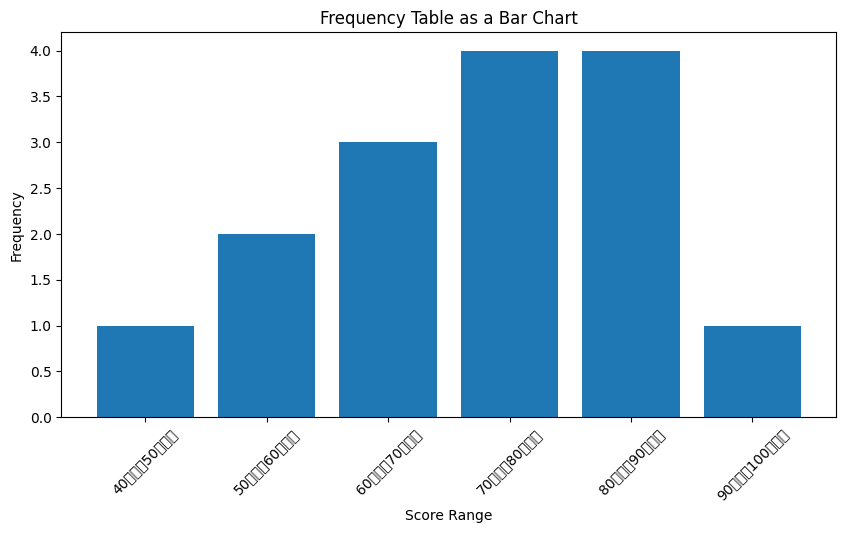

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(frequency_df['点数の範囲'], frequency_df['人数'])
plt.title('Frequency Table as a Bar Chart')
plt.xlabel('Score Range')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

## 10. ヒストグラムを描く

ヒストグラムは、度数分布表をグラフにしたものです。

`plt.hist()` を使うと、データを階級に分けて、それぞれの度数を自動的に数えてグラフにしてくれます。

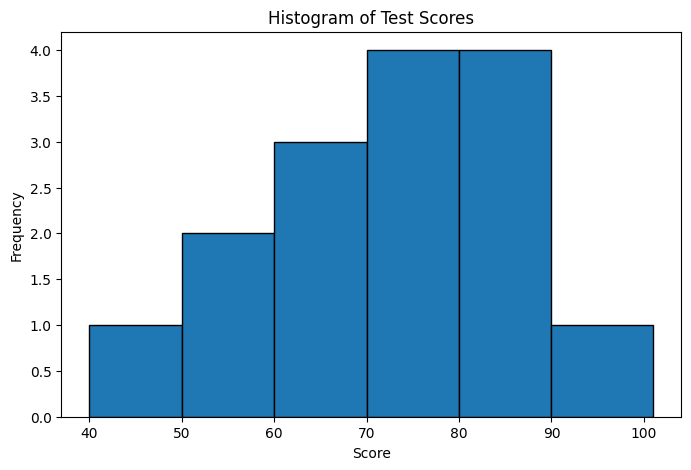

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(scores, bins=bins, edgecolor='black')
plt.title('Histogram of Test Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

## 11. 階級幅を変えると見え方が変わる

ヒストグラムは、階級幅によって見え方が変わります。

階級幅が広すぎると細かい違いが見えにくくなります。
階級幅が狭すぎると、全体の傾向が見えにくくなることがあります。

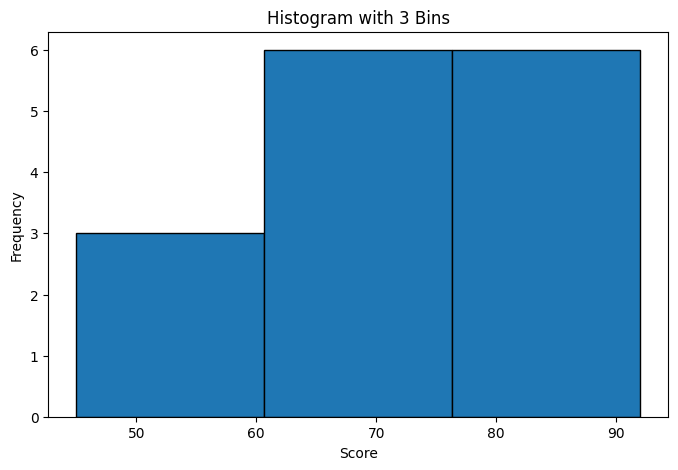

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(scores, bins=3, edgecolor='black')
plt.title('Histogram with 3 Bins')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

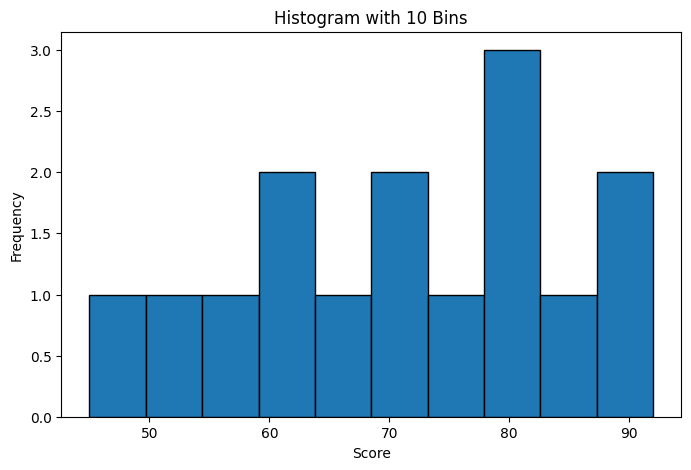

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(scores, bins=10, edgecolor='black')
plt.title('Histogram with 10 Bins')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

## 12. 分布を読み取る

ヒストグラムを見ると、次のようなことを確認できます。

- データがどこに集まっているか
- データがどのくらい散らばっているか
- 極端な値があるか
- 山が1つか、複数あるか

平均値だけでは見えないデータの姿を、ヒストグラムから観察できます。

## 13. 平均値が同じでも分布は違う

次に、平均値が近くても分布が違う例を見ます。

平均値だけを見ると似ているように見えても、ヒストグラムを見ると違いがわかることがあります。

In [15]:
class_a = [65, 68, 70, 71, 72, 73, 74, 75, 77, 80]
class_b = [40, 45, 50, 60, 70, 80, 90, 95, 100, 100]

print('クラスAの平均:', np.mean(class_a))
print('クラスBの平均:', np.mean(class_b))

クラスAの平均: 72.5
クラスBの平均: 73.0


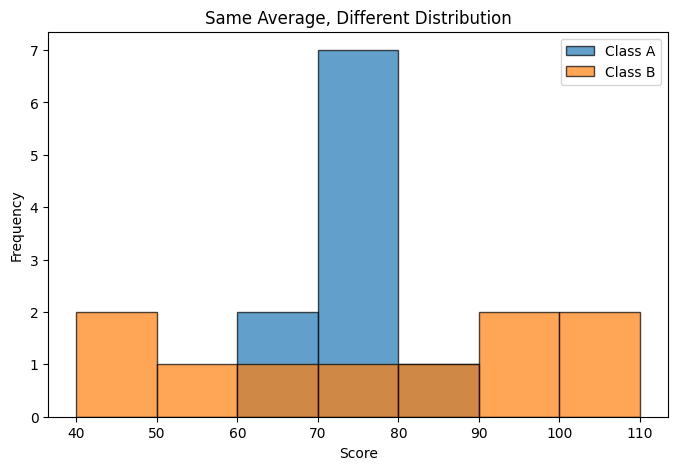

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(class_a, bins=[40, 50, 60, 70, 80, 90, 100, 110], alpha=0.7, edgecolor='black', label='Class A')
plt.hist(class_b, bins=[40, 50, 60, 70, 80, 90, 100, 110], alpha=0.7, edgecolor='black', label='Class B')
plt.title('Same Average, Different Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

クラスAは平均付近に集まっています。

一方で、クラスBは低得点と高得点に分かれています。

このように、平均値だけではクラスの状態を十分に判断できません。
分布を見ることが重要です。

## 14. ビジネスデータの例：問い合わせ対応時間

次に、ビジネス場面の例として、問い合わせ対応時間を見てみます。

単位は分とします。

In [17]:
response_times = [
    3, 4, 5, 5, 6, 7, 7, 8, 9, 10,
    10, 11, 12, 13, 14, 15, 18, 20, 25, 40
]

response_series = pd.Series(response_times)

print('平均対応時間:', response_series.mean())
print('中央値:', response_series.median())
print('最大値:', response_series.max())

平均対応時間: 12.1
中央値: 10.0
最大値: 40


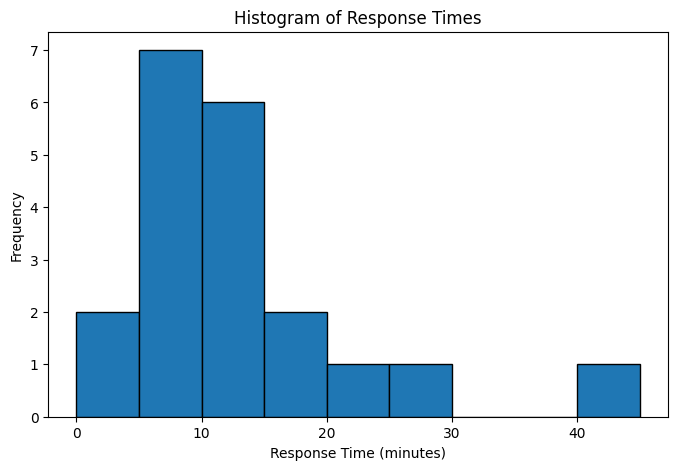

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(response_times, bins=[0, 5, 10, 15, 20, 25, 30, 35, 40, 45], edgecolor='black')
plt.title('Histogram of Response Times')
plt.xlabel('Response Time (minutes)')
plt.ylabel('Frequency')
plt.show()

このデータでは、多くの問い合わせは短時間で対応できています。

しかし、一部に時間がかかっている問い合わせがあります。

平均値だけを見ると、通常の対応状況を少し重く見積もってしまう可能性があります。
このような場合は、中央値やヒストグラムもあわせて確認することが重要です。

## 15. 演習

次の売上データについて、度数分布表とヒストグラムを作ってみましょう。

単位は円とします。

In [19]:
sales = [
    800, 1200, 1500, 1800, 2000, 2200, 2400, 2500, 2700, 3000,
    3200, 3500, 3800, 4000, 4500, 5000, 7000, 8500, 10000, 15000
]

sales

[800,
 1200,
 1500,
 1800,
 2000,
 2200,
 2400,
 2500,
 2700,
 3000,
 3200,
 3500,
 3800,
 4000,
 4500,
 5000,
 7000,
 8500,
 10000,
 15000]

### 演習1：基本的な値を確認する

売上データの平均値、中央値、標準偏差を確認してください。

In [20]:
# ここにコードを書いてください
sales_series = pd.Series(sales)

print('平均値:', sales_series.mean())
print('中央値:', sales_series.median())
print('標準偏差:', sales_series.std())

平均値: 4230.0
中央値: 3100.0
標準偏差: 3488.9449468435673


### 演習2：度数分布表を作る

売上をいくつかの範囲に分けて、度数分布表を作ってください。

In [21]:
# ここにコードを書いてください
sales_bins = [0, 3000, 6000, 9000, 12000, 16000]
sales_labels = [
    '0円以上3000円未満',
    '3000円以上6000円未満',
    '6000円以上9000円未満',
    '9000円以上12000円未満',
    '12000円以上16000円未満'
]

sales_groups = pd.cut(sales, bins=sales_bins, labels=sales_labels, right=False)
sales_frequency = sales_groups.value_counts().sort_index()

sales_frequency_df = pd.DataFrame({
    '売上の範囲': sales_frequency.index,
    '件数': sales_frequency.values
})

sales_frequency_df

,売上の範囲,件数
0,0円以上3000円未満,9
1,3000円以上6000円未満,7
2,6000円以上9000円未満,2
3,9000円以上12000円未満,1
4,12000円以上16000円未満,1


### 演習3：ヒストグラムを描く

売上データのヒストグラムを描いてください。

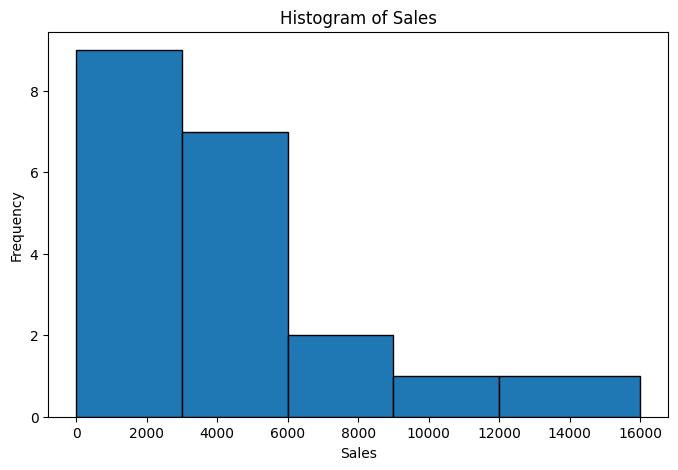

In [22]:
# ここにコードを書いてください
plt.figure(figsize=(8, 5))
plt.hist(sales, bins=sales_bins, edgecolor='black')
plt.title('Histogram of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

### 演習4：読み取ったことを書く

次の観点で、売上データから読み取れることを書いてください。

- 売上はどの範囲に多く集まっていますか
- 一部の大きな値が平均値に影響していませんか
- 平均値と中央値のどちらが、普段の売上感覚に近そうですか
- このデータを見て、ビジネス上どのような判断ができそうですか

## 16. まとめ

この章では、データの分布を確認する方法を学びました。

重要なポイントは次の通りです。

- 度数分布表は、データを範囲ごとに分けて個数を数えた表である
- ヒストグラムは、度数分布表をグラフにしたものである
- 度数とは、その範囲に含まれるデータの個数である
- 階級とは、データを分ける範囲である
- 階級幅によって、ヒストグラムの見え方は変わる
- 平均値だけでは、データの分布の形はわからない
- ビジネスでは、売上、問い合わせ時間、テスト結果などの分析に使える

次の章では、2つのデータの関係を確認するために、散布図と相関を学びます。